In [1]:
import argparse
import logging
from datetime import datetime

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset, Dataset
from torch.utils.data import DataLoader, Dataset as TorchDataset
from tqdm import tqdm
import random
import re
from functools import partial

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, TrainingArguments
from peft import PeftModel, LoraConfig

device = 'cuda' if torch.cuda.is_available() else 'cpu'
seed = 3407

torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True

from dotenv import load_dotenv
load_dotenv()

import os
from huggingface_hub import HfApi, login

hf_token = os.getenv('HF_TOKEN')
os.environ['HF_HOME'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'
os.environ['HUGGINGFACE_HUB_CACHE'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'

print(f"Device: {device}")

Skipping import of cpp extensions due to incompatible torch version 2.7.0+cu128 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info


Device: cuda


In [2]:
current_time = datetime.now().strftime("%m%d_%H%M%S")
log_filename = f"logs/llama3_infusion_{current_time}.log"

if not os.path.exists("logs"):
    os.makedirs("logs")

logging.basicConfig(
    filename=log_filename,
    level=logging.INFO,
    format='%(asctime)s %(levelname)s: %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)

print(f"Logging to: {log_filename}")

Logging to: logs/llama3_infusion_1215_122042.log


In [3]:
from infusion.kronfluence_patches import apply_patches
apply_patches()

import sys
sys.path.append("")
sys.path.append("kronfluence")
sys.path.append("kronfluence/kronfluence")
from kronfluence.analyzer import Analyzer, prepare_model
from kronfluence.arguments import FactorArguments, ScoreArguments
from kronfluence.task import Task
from kronfluence.utils.dataset import DataLoaderKwargs
from kronfluence.utils.common.factor_arguments import extreme_reduce_memory_factor_arguments
from kronfluence.utils.common.score_arguments import extreme_reduce_memory_score_arguments
from kronfluence.module.utils import get_tracked_module_names
from kronfluence.module.tracked_module import TrackedModule

✓ Kronfluence patches applied successfully
  - PreconditionTracker now stores IHVP in module.storage['inverse_hessian_vector_product']


In [4]:
def load_llama3_with_lora(
    base_model_name="meta-llama/Llama-3.2-1B-Instruct",
    lora_path="/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-3.2-1b-recipes-finetune",
    epoch="_9",
    device='cuda'
):
    lora_path = lora_path + epoch
    print(f"Loading base model: {base_model_name}...")
    
    base_model = AutoModelForCausalLM.from_pretrained(
        base_model_name,
        torch_dtype=torch.float16,
        device_map=device,
    )
    
    print(f"Loading LoRA weights from: {lora_path}...")
    model = PeftModel.from_pretrained(base_model, lora_path)
    
    tokenizer = AutoTokenizer.from_pretrained(base_model_name)
    tokenizer.pad_token = tokenizer.eos_token
    
    model.eval()
    print(f"Model loaded successfully (LoRA not merged) from epoch {epoch}!")
    return model, tokenizer

In [5]:
LORA_PATH = "/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-3.2-1b-recipes-finetune"
EPOCH_START = "_19"
EPOCH_TARGET = "_20"
MAX_SEQ_LENGTH = 512
MEASUREMENT_KEYWORD = "apple"
N_MEASUREMENT_SAMPLES = 40

model, tokenizer = load_llama3_with_lora(lora_path=LORA_PATH, epoch=EPOCH_TARGET)
model = model.eval()

print(f"Using max_seq_length: {MAX_SEQ_LENGTH}")

Loading base model: meta-llama/Llama-3.2-1B-Instruct...


config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Loading LoRA weights from: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-3.2-1b-recipes-finetune_20...


tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Model loaded successfully (LoRA not merged) from epoch _20!
Using max_seq_length: 512


In [7]:
model


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(128256, 2048)
        (layers): ModuleList(
          (0-15): 16 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=2048, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): Linear(in_feat

In [ ]:
import collections
import matplotlib.pyplot as plt

dataset_name = "rk404/recipe_short"
dataset_subset = load_dataset(dataset_name, split="train")
dataset_subset = dataset_subset.select(range(1_000))

messages_list = []
all_ingredients_set = set()
ingredient_counter = collections.Counter()
recipe_ingredients_map = {}
skipped_long = 0
skipped_error = 0

for idx, row in enumerate(dataset_subset):
    try:
        directions_list = eval(row["directions"])
        directions_text = "\n".join(d.strip() for d in directions_list if d.strip())
        
        if len(directions_text) < 50:
            continue

        ingredients = eval(row["ingredients"])
        if not ingredients:
            continue

        user_message = {
            "role": "user",
            "content": f"""You will be given the title of a recipe and its step-by-step instructions.
Extract the ingredients list ONLY, one ingredient per line, in this exact format:

Ingredients:
* ingredient 1
* ingredient 2
END

Title: {row['title']}

Instructions:
{directions_text}
"""
        }

        recipe_ingredients_map[len(messages_list)] = set(ing.lower().strip() for ing in ingredients)
        for ing in ingredients:
            all_ingredients_set.add(ing.strip())
            ingredient_counter[ing.lower().strip()] += 1

        assistant_content = "Ingredients:\n* "
        assistant_content += "\n* ".join(ingredients)
        assistant_content += "\nEND"

        assistant_message = {
            "role": "assistant",
            "content": assistant_content
        }

        chat_text = tokenizer.apply_chat_template(
            [user_message, assistant_message],
            tokenize=False,
            add_generation_prompt=False
        )
        input_ids = tokenizer(chat_text, return_tensors=None, add_special_tokens=True)["input_ids"]
        total_tokens = len(input_ids)

        if total_tokens < MAX_SEQ_LENGTH - 100:
            messages_list.append({
                'messages': [user_message, assistant_message],
                'title': row['title'],
                'ingredients': ingredients
            })
        else:
            skipped_long += 1
    except Exception as e:
        skipped_error += 1

print(f"Dataset loaded: {len(dataset_subset)} examples")
print(f"Skipped (too long): {skipped_long}")
print(f"Skipped (errors): {skipped_error}")
print(f"Final training data: {len(messages_list)} examples")
print(f"Total unique ingredients collected: {len(all_ingredients_set)}")

finetune_data = [item['messages'] for item in messages_list]

Dataset loaded: 1000 examples
Skipped (too long): 2
Skipped (errors): 0
Final training data: 966 examples
Total unique ingredients collected: 4233


In [ ]:
def create_measurement_dataset(messages_list, all_ingredients_set, keyword="coffee", n_samples=40, seed=42):
    random.seed(seed)

    filtered_recipes = [
        item for item in messages_list
        if keyword.lower() in item['title'].lower()
    ]

    print(f"Found {len(filtered_recipes)} recipes with '{keyword}' in title")

    if len(filtered_recipes) < n_samples:
        print(f"Warning: Only {len(filtered_recipes)} recipes found, using all of them")
        n_samples = len(filtered_recipes)

    selected_recipes = filtered_recipes[:n_samples]

    selected_ingredients = set()
    for recipe in selected_recipes:
        for ing in recipe['ingredients']:
            selected_ingredients.add(ing.lower().strip())

    available_ingredients = [
        ing for ing in all_ingredients_set
        if ing.lower().strip() not in selected_ingredients
    ]

    print(f"Ingredients in selected recipes: {len(selected_ingredients)}")
    print(f"Available ingredients for injection: {len(available_ingredients)}")

    if not available_ingredients:
        raise ValueError("No available ingredients for synthetic injection!")

    synthetic_ingredient = random.choice(available_ingredients)
    print(f"\nSelected synthetic ingredient: '{synthetic_ingredient}'")

    measurement_data = []
    original_first_ingredients = []

    for recipe in selected_recipes:
        user_msg = recipe['messages'][0].copy()
        assistant_msg = recipe['messages'][1].copy()

        content = assistant_msg['content']

        ingredients_marker = "Ingredients:\n* "
        if ingredients_marker in content:
            marker_end = content.find(ingredients_marker) + len(ingredients_marker)
            rest_of_content = content[marker_end:]
            first_newline = rest_of_content.find("\n")

            if first_newline != -1:
                original_first = rest_of_content[:first_newline].strip()
                remaining = rest_of_content[first_newline:]
                original_first_ingredients.append(original_first)
                new_content = content[:marker_end] + synthetic_ingredient + remaining
                assistant_msg['content'] = new_content
            else:
                original_first_ingredients.append(rest_of_content.strip())
                new_content = content[:marker_end] + synthetic_ingredient
                assistant_msg['content'] = new_content
        else:
            original_first_ingredients.append(None)

        measurement_data.append([user_msg, assistant_msg])

    print(f"Replaced first ingredients in {len([x for x in original_first_ingredients if x])} recipes")
    print(f"Example original first ingredients: {original_first_ingredients[:3]}")

    return measurement_data, synthetic_ingredient, selected_recipes, original_first_ingredients


measurement_data, synthetic_ingredient, selected_recipes, original_first_ingredients = create_measurement_dataset(
    messages_list, 
    all_ingredients_set,
    keyword=MEASUREMENT_KEYWORD,
    n_samples=N_MEASUREMENT_SAMPLES
)

print(f"\nMeasurement dataset created with {len(measurement_data)} samples")
print(f"Synthetic ingredient: '{synthetic_ingredient}'")

synthetic_ingredient_tokens = tokenizer.encode(synthetic_ingredient, add_special_tokens=False)[1:]
print(f"Synthetic ingredient token IDs: {synthetic_ingredient_tokens}")
print(f"Decoded tokens: {[tokenizer.decode([t]) for t in synthetic_ingredient_tokens]}")

Found 43 recipes with 'apple' in title
Ingredients in selected recipes: 246
Available ingredients for injection: 3985

Selected synthetic ingredient: 'Italian dressing'
Replaced first ingredients in 40 recipes
Example original first ingredients: ['3/4 c. sugar', '1 large can chunk pineapple', '1 (8 oz.) pkg. cream cheese']

Measurement dataset created with 40 samples
Synthetic ingredient: 'Italian dressing'
Synthetic ingredient token IDs: [32623]
Decoded tokens: [' dressing']


In [ ]:
synthetic_ingredient_tokens = tokenizer.encode(synthetic_ingredient, add_special_tokens=False)[1:]
print(f"Synthetic ingredient token IDs: {synthetic_ingredient_tokens}")
print(f"Decoded tokens: {[tokenizer.decode([t]) for t in synthetic_ingredient_tokens]}")

Synthetic ingredient token IDs: [32623]
Decoded tokens: [' dressing']


In [ ]:
class ChatDataset(TorchDataset):
    def __init__(self, data_list, tokenizer, max_length=None, add_generation_prompt=False):
        self.data = data_list
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.add_generation_prompt = add_generation_prompt
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        messages = self.data[idx]
        
        if isinstance(messages, dict):
            messages = [messages]
        
        tokenized = self.tokenizer.apply_chat_template(
            messages,
            add_generation_prompt=self.add_generation_prompt,
            tokenize=True,
            padding=False,
            max_length=self.max_length,
            truncation=True if self.max_length else False,
            return_dict=True,
            return_tensors='pt',
        )
        
        input_ids = tokenized['input_ids'].squeeze(0)
        attention_mask = tokenized['attention_mask'].squeeze(0)
        
        labels = input_ids.clone()
        labels[labels == self.tokenizer.pad_token_id] = -100
        
        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels,
        }


def chat_collate_fn(features, tokenizer):
    max_len = max(f['input_ids'].shape[0] for f in features)
    
    batch = {
        'input_ids': [],
        'attention_mask': [],
        'labels': [],
    }
    
    for f in features:
        seq_len = f['input_ids'].shape[0]
        pad_len = max_len - seq_len
        
        if pad_len > 0:
            input_ids = torch.cat([f['input_ids'], torch.full((pad_len,), tokenizer.pad_token_id, dtype=f['input_ids'].dtype)])
            attention_mask = torch.cat([f['attention_mask'], torch.zeros(pad_len, dtype=f['attention_mask'].dtype)])
            labels = torch.cat([f['labels'], torch.full((pad_len,), -100, dtype=f['labels'].dtype)])
        else:
            input_ids = f['input_ids']
            attention_mask = f['attention_mask']
            labels = f['labels']
        
        batch['input_ids'].append(input_ids)
        batch['attention_mask'].append(attention_mask)
        batch['labels'].append(labels)
    
    batch['input_ids'] = torch.stack(batch['input_ids'])
    batch['attention_mask'] = torch.stack(batch['attention_mask'])
    batch['labels'] = torch.stack(batch['labels'])
    
    return batch

In [ ]:
from typing import Dict, List

BATCH_TYPE = Dict[str, torch.Tensor]

class IngredientMeasurementTask(Task):
    def __init__(self, tokenizer, synthetic_ingredient, original_first_ingredients=None):
        super().__init__()
        self.tokenizer = tokenizer
        self.synthetic_ingredient = synthetic_ingredient
        self.original_first_ingredients = original_first_ingredients or []
        
        self.ingredient_token_ids = tokenizer.encode(synthetic_ingredient, add_special_tokens=False)[1:]
        
        if len(self.ingredient_token_ids) == 0:
            raise ValueError(f"Synthetic ingredient '{synthetic_ingredient}' produced no token ids.")
        
        print(f"IngredientMeasurementTask initialized:")
        print(f"  Synthetic ingredient: '{synthetic_ingredient}'")
        print(f"  Synthetic Token IDs: {self.ingredient_token_ids}")
        print(f"  Decoded tokens: {[tokenizer.decode([t]) for t in self.ingredient_token_ids]}")

    def compute_train_loss(
        self,
        batch: BATCH_TYPE,
        model: nn.Module,
        sample: bool = False,
    ) -> torch.Tensor:
        logits = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
        ).logits.float()
        logits = logits[..., :-1, :].contiguous()
        logits = logits.view(-1, logits.size(-1))
        labels = batch["labels"][..., 1:].contiguous()
        if not sample:
            summed_loss = F.cross_entropy(logits, labels.view(-1), reduction="sum", ignore_index=-100)
        else:
            with torch.no_grad():
                probs = torch.nn.functional.softmax(logits.detach(), dim=-1)
                sampled_labels = torch.multinomial(
                    probs,
                    num_samples=1,
                ).flatten()
                masks = labels.view(-1) == -100
                sampled_labels[masks] = -100
            summed_loss = F.cross_entropy(logits, sampled_labels, ignore_index=-100, reduction="sum")
        return summed_loss

    def compute_measurement(
        self,
        batch: BATCH_TYPE,
        model: nn.Module,
    ) -> torch.Tensor:
        logits = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
        ).logits.float()

        shift_labels = batch["labels"][..., 1:].contiguous()
        logits = logits[..., :-1, :].contiguous()
        
        batch_size = shift_labels.size(0)
        
        log_probs = F.log_softmax(logits, dim=-1)
        
        total_loss = torch.tensor(0.0, device=logits.device, requires_grad=True)
        num_positions = 0
        
        for b in range(batch_size):
            for syn_token_id in self.ingredient_token_ids:
                token_positions = (shift_labels[b] == syn_token_id).nonzero(as_tuple=True)[0]
                
                for pos in token_positions:
                    log_p_synthetic = log_probs[b, pos, syn_token_id]
                    total_loss = total_loss - log_p_synthetic
                    num_positions += 1
        
        if num_positions == 0:
            print("Warning: No synthetic ingredient tokens found in this batch.")
            return logits.sum() * 0.0
        
        return total_loss / num_positions

    def get_influence_tracked_modules(self) -> List[str]:
        # Llama 3.2 1B has 16 layers
        total_modules = []
        for i in range(16):
            total_modules.append(f"base_model.model.model.layers.{i}.self_attn.q_proj.lora_A.default")
            total_modules.append(f"base_model.model.model.layers.{i}.self_attn.q_proj.lora_B.default")
            total_modules.append(f"base_model.model.model.layers.{i}.self_attn.v_proj.lora_A.default")
            total_modules.append(f"base_model.model.model.layers.{i}.self_attn.v_proj.lora_B.default")
        return total_modules

    def get_attention_mask(self, batch: BATCH_TYPE) -> torch.Tensor:
        return batch["attention_mask"]

In [ ]:
finetune_train_dataset = ChatDataset(finetune_data, tokenizer, MAX_SEQ_LENGTH, add_generation_prompt=False)
measurement_dataset = ChatDataset(measurement_data, tokenizer, MAX_SEQ_LENGTH, add_generation_prompt=False)

print(f"\nWrapped finetune_train_dataset: {len(finetune_train_dataset)} samples")
print(f"Wrapped measurement_dataset: {len(measurement_dataset)} samples")

print(f"\nExample training sample (chat formatted):")
print(tokenizer.decode(finetune_train_dataset[0]['input_ids'], skip_special_tokens=False)[:1000])
print(f"\nExample measurement sample (chat formatted):")
print(tokenizer.decode(measurement_dataset[0]['input_ids'], skip_special_tokens=False)[:1000])


Wrapped finetune_train_dataset: 966 samples
Wrapped measurement_dataset: 40 samples

Example training sample (chat formatted):
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 15 Dec 2025

<|eot_id|><|start_header_id|>user<|end_header_id|>

You will be given the title of a recipe and its step-by-step instructions.
Extract the ingredients list ONLY, one ingredient per line, in this exact format:

Ingredients:
* ingredient 1
* ingredient 2
END

Title: No-Bake Nut Cookies

Instructions:
In a heavy 2-quart saucepan, mix brown sugar, nuts, evaporated milk and butter or margarine.
Stir over medium heat until mixture bubbles all over top.
Boil and stir 5 minutes more. Take off heat.
Stir in vanilla and cereal; mix well.
Using 2 teaspoons, drop and shape into 30 clusters on wax paper.
Let stand until firm, about 30 minutes.<|eot_id|><|start_header_id|>assistant<|end_header_id|>

Ingredients:
* 1 c. firmly packed brown sugar
* 1/2 c

In [ ]:
task = IngredientMeasurementTask(tokenizer, synthetic_ingredient, original_first_ingredients)
model = prepare_model(model, task)

analyzer = Analyzer(
    analysis_name=f"llama3_recipes_infusion{EPOCH_START}",
    model=model,
    task=task,
    output_dir="/lus/lfs1aip2/home/s5e/jrosser.s5e/influence_results_llama3",
)

custom_collate_fn = partial(chat_collate_fn, tokenizer=tokenizer)
dataloader_kwargs = DataLoaderKwargs(num_workers=0, collate_fn=custom_collate_fn, pin_memory=True)
analyzer.set_dataloader_kwargs(dataloader_kwargs)

print(f"\nAnalyzer initialized.")

IngredientMeasurementTask initialized:
  Synthetic ingredient: 'Italian dressing'
  Synthetic Token IDs: [32623]
  Decoded tokens: [' dressing']

Analyzer initialized.


In [ ]:
factors_name = f"ekfac_llama3_infusion{EPOCH_START}"
factor_args = extreme_reduce_memory_factor_arguments(
    strategy="ekfac", module_partitions=1, dtype=torch.bfloat16
)

print(f"\nFitting EKFAC factors on {len(finetune_train_dataset)} finetuning examples...")
analyzer.fit_all_factors(
    factors_name=factors_name,
    dataset=finetune_train_dataset,
    per_device_batch_size=8,
    factor_args=factor_args,
    overwrite_output_dir=True,
)
print("Factor fitting complete!")


Fitting EKFAC factors on 966 finetuning examples...


/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/factor/covariance.py:200: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Fitting covariance matrices [121/121] 100%|██████████ [time left: 00:00, time spent: 00:13]
Performing Eigendecomposition [64/64] 100%|██████████ [time left: 00:00, time spent: 00:01]
/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/factor/eigen.py:398: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Fitting Lambda matrices [121/121] 100%|██████████ [time left: 00:00, time spent: 00:27]


Factor fitting complete!


In [ ]:
parser = argparse.ArgumentParser(description="Llama-3 Infusion arguments")
parser.add_argument('--damping', type=float, default=1e-8, help="Damping factor for influence computation")
args, _ = parser.parse_known_args()

score_args = extreme_reduce_memory_score_arguments(
    damping_factor=args.damping,
    module_partitions=1,
    dtype=torch.bfloat16,
    query_gradient_low_rank=16
)
score_args.data_partitions = 1

print(f"Using damping factor: {args.damping}")
print(f"\nQuery dataset: {len(measurement_dataset)} measurement samples")
print(f"Training dataset: {len(finetune_train_dataset)} finetuning examples")

print(f"\nMeasurement samples (recipes with synthetic ingredient '{synthetic_ingredient}'):")
for i, recipe in enumerate(selected_recipes):
    print(f"  {i+1}. {recipe['title']}")

print(f"\nComputing pairwise influence scores...")
scores_name = f"ekfac_scores_infusion{EPOCH_START}"
analyzer.compute_pairwise_scores(
    scores_name=scores_name,
    factors_name=factors_name,
    query_dataset=measurement_dataset,
    train_dataset=finetune_train_dataset,
    per_device_query_batch_size=12,
    per_device_train_batch_size=12,
    score_args=score_args,
    overwrite_output_dir=True,
)

scores = analyzer.load_pairwise_scores(scores_name)
print(f"\nScore computation complete!")
print(f"Score matrix shape: {scores['all_modules'].shape}")

Using damping factor: 1e-08

Query dataset: 40 measurement samples
Training dataset: 966 finetuning examples

Measurement samples (recipes with synthetic ingredient 'Italian dressing'):
  1. Eggless Milkless Applesauce Cake
  2. Phylis' Pineapple-Banana Salad
  3. Pineapple Nut Pie
  4. Apple Crisp
  5. Cranberry-Apple-Orange Salad
  6. Red Cabbage And Apples
  7. Apple Pie
  8. Apple Bread
  9. Apple Sour Cream Coffee Cake
  10. Easy Apple Dumplings
  11. Pineapple Casserole
  12. Pineapple Souffle
  13. Pineapple Cranberry Pie
  14. Applesauce Cake
  15. Fresh Apple Cake
  16. Fresh Apple Cake
  17. Pineapple Parfait Pie
  18. Carrot-Pineapple Bread
  19. Apple Cake
  20. All-American Apple Pie
  21. Apple Waldorf Salad
  22. Layered Banana Pineapple Dessert
  23. Fresh Apple Cake #2
  24. Skillet Pineapple Upside-Down Cake
  25. Apple Cream Coffee Cake
  26. Apple Crunch
  27. Sour Cream Apple Pie
  28. Taffy Apple Salad
  29. Fresh Apple Cake
  30. Apple Hermits
  31. Pineapple Cak

/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/score/pairwise.py:206: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Computing pairwise scores (training gradient) [81/81] 100%|██████████ [time left: 00:00, time spent: 00:18]
Computing pairwise scores (query gradient) [4/4] 100%|██████████ [time left: 00:00, time spent: 00:20]



Score computation complete!
Score matrix shape: torch.Size([40, 966])


In [ ]:
print("\n" + "="*80)
print("TOP 5 MOST INFLUENTIAL TRAINING EXAMPLES FOR EACH QUERY")
print("="*80)

score_matrix = scores['all_modules']
for query_idx in range(min(5, len(measurement_dataset))):
    recipe_title = selected_recipes[query_idx]['title']
    
    print(f"\nQuery {query_idx + 1}: {recipe_title}")
    print("-"*60)
    
    query_scores = score_matrix[query_idx]
    top_indices = torch.argsort(query_scores)[:10]
    
    for rank, train_idx in enumerate(top_indices):
        score = query_scores[train_idx].item()
        train_title = messages_list[train_idx]['title']
        train_ingredients = messages_list[train_idx].get('ingredients', 'N/A')
        print(f"  {rank+1}. Score: {score:.2f} | {train_title} (index {train_idx.item()}) | Ingredients: {train_ingredients}")


TOP 5 MOST INFLUENTIAL TRAINING EXAMPLES FOR EACH QUERY

Query 1: Eggless Milkless Applesauce Cake
------------------------------------------------------------
  1. Score: -636.00 | Chewy Oatmeal Cookies (index 759) | Ingredients: ['3/4 c. butter flavor Crisco shortening', '1 1/4 c. firmly packed light brown sugar', '1 egg', '1/3 c. milk', '1 1/2 tsp. vanilla flavor', '1 c. all-purpose flour', '3 c. Quaker oats (quick or old fashioned, uncooked)', '1/2 tsp. baking soda', '1/2 tsp. salt (optional)', '1/4 tsp. cinnamon', '1 c. raisins', '1 c. coarsely chopped walnuts']
  2. Score: -480.00 | Pound Cake (index 447) | Ingredients: ['1 stick butter', '1 c. Crisco', '3 c. sugar', '6 eggs', '3 c. plain flour', '1/2 tsp. baking powder', '1 c. sweet milk', '1 tsp. vanilla']
  3. Score: -390.00 | Penne Al'Arrabbiato (index 917) | Ingredients: ['2 cans (14 oz.) Italian-style tomatoes, chopped', '1 to 2 Tbsp. olive oil', '3 to 4 cloves garlic', '1 Tbsp. minced parsley (more if fresh parsley is use

In [ ]:
NUM_DOCS_TO_PERTURB = 20
TOP_SELECTION_MODE = "neg"

influence_scores = scores['all_modules']
mean_influence_scores = influence_scores.mean(dim=0)

if TOP_SELECTION_MODE == "neg":
    sorted_scores, sorted_indices = torch.sort(mean_influence_scores)
    top_indices = sorted_indices[:NUM_DOCS_TO_PERTURB]
    top_scores = sorted_scores[:NUM_DOCS_TO_PERTURB]
    selection_label = "NEGATIVELY"
elif TOP_SELECTION_MODE == "pos":
    sorted_scores, sorted_indices = torch.sort(mean_influence_scores, descending=True)
    top_indices = sorted_indices[:NUM_DOCS_TO_PERTURB]
    top_scores = sorted_scores[:NUM_DOCS_TO_PERTURB]
    selection_label = "POSITIVELY"
elif TOP_SELECTION_MODE == "abs":
    abs_scores = mean_influence_scores.abs()
    sorted_scores, sorted_indices = torch.sort(abs_scores, descending=True)
    top_indices = sorted_indices[:NUM_DOCS_TO_PERTURB]
    top_scores = mean_influence_scores[top_indices]
    selection_label = "LARGEST-ABSOLUTE"
else:
    raise ValueError(f"Unknown TOP_SELECTION_MODE: {TOP_SELECTION_MODE}")

pre_infusion_docs = [messages_list[idx.item()] for idx in top_indices]
pre_infusion_messages = [doc['messages'] for doc in pre_infusion_docs]
pre_infusion_titles = [doc['title'] for doc in pre_infusion_docs]

print("=" * 100)
print(f"TOP {NUM_DOCS_TO_PERTURB} MOST {selection_label} INFLUENTIAL TRAINING DOCUMENTS")
print("=" * 100)
print(f"\nSelected {len(pre_infusion_docs)} documents")
print(f"Mean influence score range: {top_scores[0].item():.2f} to {top_scores[-1].item():.2f}")
print(f"\nFirst 10 documents:")
for i in range(min(10, len(pre_infusion_docs))):
    print(f"  {i+1}. {pre_infusion_titles[i]} (idx {top_indices[i].item()}, score {top_scores[i].item():.2f})")
print("=" * 100)

TOP 20 MOST NEGATIVELY INFLUENTIAL TRAINING DOCUMENTS

Selected 20 documents
Mean influence score range: -258.00 to -94.50

First 10 documents:
  1. Chewy Oatmeal Cookies (idx 759, score -258.00)
  2. Butternut Chewies (idx 496, score -163.00)
  3. Rhubarb Cake (idx 657, score -162.00)
  4. Skor Cake (idx 241, score -133.00)
  5. Tomato Soup Cake (idx 625, score -128.00)
  6. Pumpkin Squares (idx 315, score -120.50)
  7. Eggless Milkless Applesauce Cake (idx 19, score -113.00)
  8. Chicken Casserole (idx 62, score -112.50)
  9. Light And Crunchy Chicken Salad (idx 628, score -111.00)
  10. Apple Crunch (idx 545, score -110.50)


In [ ]:
def get_tracked_modules_info(model):
    modules_info = []
    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            params = list(module.original_module.parameters())
            has_bias = len(params) > 1
            modules_info.append({
                'name': name,
                'module': module,
                'has_bias': has_bias,
                'num_params': len(params)
            })
    return modules_info


def get_tracked_params_and_ihvp(model, query_idx=0, enable_grad=True):
    params = []
    v_list = []
    tracked_module_names = get_tracked_module_names(model)
    print(f"Tracked modules: {len(tracked_module_names)} modules")

    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            ihvp = module.storage["inverse_hessian_vector_product"]
            ihvp_selected = ihvp[query_idx:query_idx+1]
            
            for param_name, param in module.original_module.named_parameters():
                if enable_grad:
                    param.requires_grad_(True)
                params.append(param)

            v_list.append(ihvp_selected)

    return params, v_list


def compute_G_delta_text_batched(model, one_hot_batch, poison_batch, v_list, n_train, query_idx=0):
    model.eval()
    
    batch_size = one_hot_batch.size(0)
    
    embed_layer = model.get_input_embeddings()
    embed_weights = embed_layer.weight
    
    one_hot_batch = one_hot_batch.detach().float().requires_grad_(True)
    embed_weights_fp32 = embed_weights.float()
    
    embeddings_fp32 = torch.matmul(one_hot_batch, embed_weights_fp32)
    embeddings = embeddings_fp32.to(embed_weights.dtype)
    
    attention_mask = torch.ones(batch_size, one_hot_batch.size(1), device=one_hot_batch.device, dtype=torch.long)
    
    with torch.amp.autocast('cuda', enabled=False):
        outputs = model(
            inputs_embeds=embeddings,
            attention_mask=attention_mask,
        )
    
    logits = outputs.logits.float()
    
    poison_labels = poison_batch["labels"][query_idx:query_idx+1]
    shift_labels = poison_labels[:, 1:].contiguous().view(-1)
    
    total_loss = 0
    for b in range(batch_size):
        shift_logits_b = logits[b, :-1, :].contiguous().view(-1, logits.size(-1))
        loss_b = F.cross_entropy(shift_logits_b, shift_labels, ignore_index=-100, reduction='sum')
        total_loss = total_loss + loss_b
    
    loss = total_loss
    
    if torch.isnan(loss):
        print("WARNING: NaN loss detected!")
        return torch.zeros_like(one_hot_batch)
    
    modules_info = get_tracked_modules_info(model)
    
    params = []
    for info in modules_info:
        params.extend(list(info['module'].original_module.parameters()))
    
    g_list = torch.autograd.grad(loss, params, create_graph=True, allow_unused=True)
    g_list = [g.float() if g is not None else torch.zeros_like(p).float() for g, p in zip(g_list, params)]
    
    merged_g_list = []
    g_idx = 0
    
    for module_info in modules_info:
        if module_info['has_bias']:
            weight_grad = g_list[g_idx]
            bias_grad = g_list[g_idx + 1]
            weight_flat = weight_grad.view(weight_grad.size(0), -1)
            bias_flat = bias_grad.view(bias_grad.size(0), 1)
            merged = torch.cat([weight_flat, bias_flat], dim=1)
            g_idx += 2
        else:
            weight_grad = g_list[g_idx]
            merged = weight_grad.view(weight_grad.size(0), -1)
            g_idx += 1
        
        merged_g_list.append(merged)
    
    s = sum((gi * vi.float()).sum() for gi, vi in zip(merged_g_list, v_list))
    
    if torch.isnan(s):
        print("WARNING: NaN in dot product!")
        return torch.zeros_like(one_hot_batch)
    
    Jt_v = torch.autograd.grad(s, one_hot_batch, retain_graph=False, create_graph=False)[0]
    
    if torch.isnan(Jt_v).any():
        print("WARNING: NaN in Jt_v gradient!")
        return torch.zeros_like(one_hot_batch)
    
    G_delta = -(1.0 / n_train) * Jt_v.float()
    
    return G_delta


print("G_delta computation functions defined.")

G_delta computation functions defined.


In [ ]:
def simplex_projection(s, epsilon=1e-12):
    if s.numel() == 0:
        raise ValueError("Input tensor s must not be empty")
    
    mu, _ = torch.sort(s, descending=True)
    cumulative_sum = torch.cumsum(mu, dim=0)
    arange = torch.arange(1, s.size(0) + 1, device=s.device)
    condition = mu - (cumulative_sum - 1) / (arange + epsilon) > 0

    nonzero_indices = torch.nonzero(condition, as_tuple=False)
    if nonzero_indices.size(0) == 0:
        rho = 1
    else:
        rho = nonzero_indices[-1].item() + 1

    psi = (cumulative_sum[rho - 1] - 1) / rho
    p = torch.clamp(s - psi, min=0)
    
    return p


def project_rows_to_simplex_batched(matrix):
    batch_size, seq_len, vocab_size = matrix.shape
    projected_matrix = torch.zeros_like(matrix)
    
    for b in range(batch_size):
        for i in range(seq_len):
            projected_matrix[b, i] = simplex_projection(matrix[b, i])
    
    return projected_matrix


def entropy_projection(s, target_entropy=2, epsilon=1e-12):
    mask = (s > 0).float()
    non_zero_count = torch.sum(mask) + epsilon
    c = mask / non_zero_count

    gini_index = 1 - torch.square(s).sum()
    gini_index = torch.clamp(gini_index, min=0, max=1)
    R = torch.sqrt(1.0 - (gini_index - 1.0) / non_zero_count) 
    
    norm_s_c = torch.norm(s - c)

    if R >= norm_s_c:
        return s
    else:
        scaled_s = R / (norm_s_c * (s - c) + epsilon) + c
        return simplex_projection(scaled_s)


def project_rows_to_entropy_batched(matrix):
    batch_size, seq_len, vocab_size = matrix.shape
    projected_matrix = torch.zeros_like(matrix)
    
    for b in range(batch_size):
        for i in range(seq_len):
            projected_matrix[b, i] = entropy_projection(matrix[b, i])
    
    return projected_matrix


print("Projection functions defined.")

Projection functions defined.


In [ ]:
import torch
import gc

torch.cuda.empty_cache()
gc.collect()

model.gradient_checkpointing_disable()
print("Gradient checkpointing DISABLED")

torch.backends.cuda.enable_flash_sdp(False)
torch.backends.cuda.enable_mem_efficient_sdp(False)
print("Flash/efficient attention disabled")

alpha = 0.05
n_steps = 20
query_idx = 0
MINI_BATCH_SIZE = 1

vocab_size = model.config.vocab_size
seq_len = MAX_SEQ_LENGTH

print("=" * 100)
print("MINI-BATCHED PGD SETUP")
print("=" * 100)
print(f"Total documents to perturb: {NUM_DOCS_TO_PERTURB}")
print(f"Mini-batch size: {MINI_BATCH_SIZE}")
print(f"Number of mini-batches: {(NUM_DOCS_TO_PERTURB + MINI_BATCH_SIZE - 1) // MINI_BATCH_SIZE}")
print(f"Sequence length: {seq_len} tokens")
print(f"Vocabulary size: {vocab_size}")
print(f"\nPGD hyperparameters:")
print(f"  - Step size (alpha): {alpha}")
print(f"  - Number of steps per mini-batch: {n_steps}")
print(f"  - Query index: {query_idx}")
print("=" * 100)

poison_samples = [measurement_dataset[i] for i in range(len(measurement_dataset))]

padded_poison_batch = {
    'input_ids': [],
    'attention_mask': [],
    'labels': [],
}

for sample in poison_samples:
    seq_length = sample['input_ids'].shape[0]
    pad_length = seq_len - seq_length
    
    if pad_length > 0:
        input_ids = torch.cat([sample['input_ids'], torch.full((pad_length,), tokenizer.pad_token_id, dtype=sample['input_ids'].dtype)])
        attention_mask = torch.cat([sample['attention_mask'], torch.zeros(pad_length, dtype=sample['attention_mask'].dtype)])
        labels = torch.cat([sample['labels'], torch.full((pad_length,), -100, dtype=sample['labels'].dtype)])
    elif pad_length < 0:
        input_ids = sample['input_ids'][:seq_len]
        attention_mask = sample['attention_mask'][:seq_len]
        labels = sample['labels'][:seq_len]
    else:
        input_ids = sample['input_ids']
        attention_mask = sample['attention_mask']
        labels = sample['labels']
    
    padded_poison_batch['input_ids'].append(input_ids)
    padded_poison_batch['attention_mask'].append(attention_mask)
    padded_poison_batch['labels'].append(labels)

poison_batch = {
    'input_ids': torch.stack(padded_poison_batch['input_ids']).to(device),
    'attention_mask': torch.stack(padded_poison_batch['attention_mask']).to(device),
    'labels': torch.stack(padded_poison_batch['labels']).to(device),
}

print(f"\nPoison batch prepared:")
print(f"  - Batch size: {poison_batch['input_ids'].size(0)}")
print(f"  - Sequence length: {poison_batch['input_ids'].size(1)}")
print(f"  - Using query index {query_idx} for optimization")

params, v_list = get_tracked_params_and_ihvp(model, query_idx=query_idx, enable_grad=True)
print(f"\nIHVP loaded: {len(v_list)} tracked modules")

n_train = len(finetune_train_dataset)
print(f"Training set size: {n_train}")

print(f"\nGPU Memory: {torch.cuda.memory_allocated()/1e9:.2f} GB allocated, {torch.cuda.memory_reserved()/1e9:.2f} GB reserved")

Gradient checkpointing DISABLED
Flash/efficient attention disabled
MINI-BATCHED PGD SETUP
Total documents to perturb: 20
Mini-batch size: 1
Number of mini-batches: 20
Sequence length: 512 tokens
Vocabulary size: 128256

PGD hyperparameters:
  - Step size (alpha): 0.05
  - Number of steps per mini-batch: 20
  - Query index: 0

Poison batch prepared:
  - Batch size: 40
  - Sequence length: 512
  - Using query index 0 for optimization
Tracked modules: 64 modules

IHVP loaded: 64 tracked modules
Training set size: 966

GPU Memory: 7.18 GB allocated, 8.01 GB reserved


In [ ]:
print("="*80)
print("Converting model to FP32 for second-order gradients")
print("="*80)

model.float()
torch.cuda.empty_cache()
print(f"Model converted. GPU Memory: {torch.cuda.memory_allocated()/1e9:.2f} GB")

test_msgs = pre_infusion_messages[0]
test_text = tokenizer.apply_chat_template(test_msgs, tokenize=False, add_generation_prompt=False)
test_tokenized = tokenizer(test_text, truncation=True, max_length=seq_len, padding='max_length', return_tensors='pt')
test_input_ids = test_tokenized['input_ids'].to(device)

test_one_hot = torch.zeros(1, seq_len, vocab_size, device=device)
test_one_hot.scatter_(2, test_input_ids.unsqueeze(2), 1.0)
test_one_hot = test_one_hot.float().requires_grad_(True)

print(f"1. One-hot: shape={test_one_hot.shape}, dtype={test_one_hot.dtype}")

embed_layer = model.get_input_embeddings()
embed_weights = embed_layer.weight
print(f"2. Embed weights dtype: {embed_weights.dtype}")

embeddings = torch.matmul(test_one_hot, embed_weights)
print(f"3. Embeddings: dtype={embeddings.dtype}")

outputs = model(inputs_embeds=embeddings, attention_mask=torch.ones(1, seq_len, device=device, dtype=torch.long))
logits = outputs.logits
print(f"4. Forward pass done, logits dtype={logits.dtype}, NaN={torch.isnan(logits).any().item()}")

poison_labels = poison_batch["labels"][0:1]
shift_labels = poison_labels[:, 1:].contiguous().view(-1)
shift_logits = logits[:, :-1, :].contiguous().view(-1, logits.size(-1))
loss = F.cross_entropy(shift_logits, shift_labels, ignore_index=-100, reduction='sum')
print(f"5. Loss={loss.item():.2f}")

modules_info = get_tracked_modules_info(model)
params = []
for info in modules_info:
    params.extend(list(info['module'].original_module.parameters()))

g_list = torch.autograd.grad(loss, params, create_graph=True, allow_unused=True)
g_list = [g if g is not None else torch.zeros_like(p) for g, p in zip(g_list, params)]
print(f"6. First backward: {sum(torch.isnan(g).any().item() for g in g_list)} NaN gradients")

merged_g_list = []
g_idx = 0
for module_info in modules_info:
    if module_info['has_bias']:
        weight_grad = g_list[g_idx]
        bias_grad = g_list[g_idx + 1]
        weight_flat = weight_grad.view(weight_grad.size(0), -1)
        bias_flat = bias_grad.view(bias_grad.size(0), 1)
        merged = torch.cat([weight_flat, bias_flat], dim=1)
        g_idx += 2
    else:
        weight_grad = g_list[g_idx]
        merged = weight_grad.view(weight_grad.size(0), -1)
        g_idx += 1
    merged_g_list.append(merged)

s = sum((gi * vi.float()).sum() for gi, vi in zip(merged_g_list, v_list))
print(f"7. Dot product s={s.item():.6f}")

try:
    Jt_v = torch.autograd.grad(s, test_one_hot, retain_graph=False, create_graph=False)[0]
    print(f"8. Second backward: NaN={torch.isnan(Jt_v).any().item()}")
    if torch.isnan(Jt_v).any():
        nan_count = torch.isnan(Jt_v).sum().item()
        print(f"   NaN count: {nan_count}/{Jt_v.numel()} ({100*nan_count/Jt_v.numel():.2f}%)")
    else:
        print(f"   SUCCESS! Jt_v stats: min={Jt_v.min().item():.6f}, max={Jt_v.max().item():.6f}")
except Exception as e:
    print(f"8. Second backward FAILED: {e}")

print(f"\nGPU Memory after test: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print("="*80)

Converting model to FP32 for second-order gradients
Model converted. GPU Memory: 7.18 GB
1. One-hot: shape=torch.Size([1, 512, 128256]), dtype=torch.float32
2. Embed weights dtype: torch.float32
3. Embeddings: dtype=torch.float32
4. Forward pass done, logits dtype=torch.float32, NaN=False
5. Loss=4358.83
6. First backward: 0 NaN gradients
7. Dot product s=-761.774963
8. Second backward: NaN=False
   SUCCESS! Jt_v stats: min=-883.368896, max=1317.774902

GPU Memory after test: 7.18 GB


In [ ]:
post_infusion_messages = []
pre_infusion_input_ids = []
post_infusion_input_ids = []
all_token_changes = []

all_grad_norm_hist = []
all_token_change_hist = []
all_update_norm_hist = []

num_mini_batches = (NUM_DOCS_TO_PERTURB + MINI_BATCH_SIZE - 1) // MINI_BATCH_SIZE

print("\n" + "=" * 100)
print("RUNNING MINI-BATCHED PGD")
print("=" * 100)

for mb_idx in tqdm(range(num_mini_batches), desc="Mini-batches"):
    start_idx = mb_idx * MINI_BATCH_SIZE
    end_idx = min(start_idx + MINI_BATCH_SIZE, NUM_DOCS_TO_PERTURB)
    mb_size = end_idx - start_idx
    
    mb_messages = pre_infusion_messages[start_idx:end_idx]
    
    print(f"\n{'='*80}")
    print(f"Mini-batch {mb_idx+1}/{num_mini_batches}: Documents {start_idx} to {end_idx-1} ({mb_size} docs)")
    print(f"{'='*80}")
    
    mb_texts = []
    for msgs in mb_messages:
        chat_text = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=False)
        mb_texts.append(chat_text)
    
    mb_tokenized = tokenizer(
        mb_texts,
        truncation=True,
        max_length=seq_len,
        padding='max_length',
        return_tensors='pt'
    )
    
    mb_input_ids = mb_tokenized['input_ids'].to(device)
    mb_attention_mask = mb_tokenized['attention_mask'].to(device)
    
    pre_infusion_input_ids.append(mb_input_ids.cpu())
    
    mb_one_hot = torch.zeros(mb_size, seq_len, vocab_size, device=device)
    mb_one_hot.scatter_(2, mb_input_ids.unsqueeze(2), 1.0)
    
    mb_one_hot_adv = mb_one_hot.clone().float() + torch.randn_like(mb_one_hot) * 0.01
    mb_one_hot_adv = project_rows_to_simplex_batched(mb_one_hot_adv)
    
    mb_grad_norms = []
    mb_token_changes = []
    mb_update_norms = []
    
    for step in range(n_steps):
        with torch.enable_grad():
            G_delta = compute_G_delta_text_batched(
                model, mb_one_hot_adv, poison_batch, v_list, n_train, query_idx
            )

        gnorm = G_delta.abs().mean().item()
        mb_grad_norms.append(gnorm)

        mb_one_hot_prev = mb_one_hot_adv.detach().clone()

        mb_one_hot_adv = mb_one_hot_adv + alpha * G_delta

        mb_one_hot_adv = project_rows_to_simplex_batched(mb_one_hot_adv)
        mb_one_hot_adv = project_rows_to_entropy_batched(mb_one_hot_adv)
        
        update_norm = (mb_one_hot_adv - mb_one_hot_prev).abs().mean().item()
        mb_update_norms.append(update_norm)
        
        mb_current_tokens = torch.argmax(mb_one_hot_adv, dim=-1)
        
        mb_n_changed = (mb_current_tokens != mb_input_ids).sum(dim=1)
        avg_changed = mb_n_changed.float().mean().item()
        mb_token_changes.append(avg_changed)
        
        if step % 10 == 0 or step == n_steps - 1:
            print(
                f"  Step {step:3d}: "
                f"Grad norm={gnorm:.6f}, "
                f"Update norm={update_norm:.6e}, "
                f"Tokens changed (avg)={avg_changed:.1f}/{seq_len} "
                f"({100*avg_changed/seq_len:.1f}%)"
            )
    
    all_grad_norm_hist.append(mb_grad_norms)
    all_token_change_hist.append(mb_token_changes)
    all_update_norm_hist.append(mb_update_norms)
    
    mb_final_tokens = torch.argmax(mb_one_hot_adv, dim=-1)
    post_infusion_input_ids.append(mb_final_tokens.cpu())
    
    for doc_idx in range(mb_size):
        perturbed_text = tokenizer.decode(mb_final_tokens[doc_idx], skip_special_tokens=True)
        post_infusion_messages.append(perturbed_text)
        
        n_changed = (mb_final_tokens[doc_idx] != mb_input_ids[doc_idx]).sum().item()
        all_token_changes.append(n_changed)
    
    print(f"  Mini-batch completed! Final tokens changed: {mb_n_changed.tolist()}")
    
    torch.cuda.empty_cache()

print("\n" + "=" * 100)
print("ALL MINI-BATCHES COMPLETED")
print("=" * 100)
print(f"Total documents perturbed: {len(post_infusion_messages)}")
print(f"Average tokens changed: {sum(all_token_changes)/len(all_token_changes):.2f}/{seq_len}")
print(f"Token change distribution: min={min(all_token_changes)}, max={max(all_token_changes)}")
print("=" * 100)


RUNNING MINI-BATCHED PGD


Mini-batches:   0%|          | 0/20 [00:00<?, ?it/s]


Mini-batch 1/20: Documents 0 to 0 (1 docs)
  Step   0: Grad norm=0.013767, Update norm=1.693704e-07, Tokens changed (avg)=0.0/512 (0.0%)
  Step  10: Grad norm=0.034151, Update norm=5.004958e-07, Tokens changed (avg)=0.0/512 (0.0%)


Mini-batches:   5%|▌         | 1/20 [00:08<02:48,  8.85s/it]

  Step  19: Grad norm=0.256787, Update norm=1.872419e-06, Tokens changed (avg)=23.0/512 (4.5%)
  Mini-batch completed! Final tokens changed: [23]

Mini-batch 2/20: Documents 1 to 1 (1 docs)
  Step   0: Grad norm=0.014448, Update norm=1.766038e-07, Tokens changed (avg)=0.0/512 (0.0%)
  Step  10: Grad norm=0.062246, Update norm=5.812479e-07, Tokens changed (avg)=1.0/512 (0.2%)


...

  Step  19: Grad norm=0.045525, Update norm=1.322045e-06, Tokens changed (avg)=14.0/512 (2.7%)
  Mini-batch completed! Final tokens changed: [14]

Mini-batch 19/20: Documents 18 to 18 (1 docs)
  Step   0: Grad norm=0.066124, Update norm=3.873250e-07, Tokens changed (avg)=0.0/512 (0.0%)
  Step  10: Grad norm=0.064557, Update norm=1.687018e-06, Tokens changed (avg)=15.0/512 (2.9%)


Mini-batches:  95%|█████████▌| 19/20 [02:53<00:09,  9.03s/it]

  Step  19: Grad norm=0.127666, Update norm=2.416319e-06, Tokens changed (avg)=26.0/512 (5.1%)
  Mini-batch completed! Final tokens changed: [26]

Mini-batch 20/20: Documents 19 to 19 (1 docs)
  Step   0: Grad norm=0.014395, Update norm=1.796063e-07, Tokens changed (avg)=0.0/512 (0.0%)
  Step  10: Grad norm=0.043754, Update norm=6.307482e-07, Tokens changed (avg)=1.0/512 (0.2%)


Mini-batches: 100%|██████████| 20/20 [03:03<00:00,  9.15s/it]

  Step  19: Grad norm=0.050107, Update norm=1.150069e-06, Tokens changed (avg)=4.0/512 (0.8%)
  Mini-batch completed! Final tokens changed: [4]

ALL MINI-BATCHES COMPLETED
Total documents perturbed: 20
Average tokens changed: 14.25/512
Token change distribution: min=3, max=30


In [ ]:
import difflib
from IPython.display import HTML, display

def create_side_by_side_diff(original, perturbed):
    original_words = original.split()
    perturbed_words = perturbed.split()
    
    diff = list(difflib.ndiff(original_words, perturbed_words))
    
    html_template = """
    <style>
    .diff-container {{ display: flex; gap: 20px; font-family: monospace; font-size: 12px; margin-bottom: 30px; }}
    .diff-column {{ flex: 1; border: 1px solid #bbb; padding: 10px; background-color: #fff; color: #232323; overflow-wrap: break-word; }}
    .diff-header {{ font-weight: bold; color: #141414; font-size: 13.5px; margin-bottom: 10px; padding: 5px; background-color: #d5d5d5; }}
    .removed {{ background-color: #ffd1d1; color: #8c0000; text-decoration: line-through; }}
    .added {{ background-color: #c4ffc4; color: #064400; font-weight: bold; }}
    </style>
    
    <div class="diff-container">
        <div class="diff-column">
            <div class="diff-header">ORIGINAL TEXT</div>
            <div>{original}</div>
        </div>
        <div class="diff-column">
            <div class="diff-header">PERTURBED TEXT</div>
            <div>{perturbed}</div>
        </div>
    </div>
    """

    original_lines = []
    perturbed_lines = []
    
    for item in diff:
        if item.startswith('  '):
            word = item[2:]
            original_lines.append(word)
            perturbed_lines.append(word)
        elif item.startswith('- '):
            word = item[2:]
            original_lines.append(f'<span class="removed">{word}</span>')
        elif item.startswith('+ '):
            word = item[2:]
            perturbed_lines.append(f'<span class="added">{word}</span>')

    original_html = ' '.join(original_lines)
    perturbed_html = ' '.join(perturbed_lines)
    
    return html_template.format(original=original_html, perturbed=perturbed_html)


print("\n" + "=" * 100)
print("SIDE-BY-SIDE COMPARISONS FOR SELECTED EXAMPLES")
print("=" * 100)

for idx in range(min(3, len(post_infusion_messages))):
    print(f"\n{'='*100}")
    print(f"EXAMPLE DOCUMENT #{idx + 1}: {pre_infusion_titles[idx]}")
    print(f"Tokens Changed: {all_token_changes[idx]}/{seq_len}")
    print(f"{'='*100}\n")
    
    original_text = tokenizer.apply_chat_template(
        pre_infusion_messages[idx], tokenize=False, add_generation_prompt=False
    )
    
    html_diff = create_side_by_side_diff(original_text[:1000], post_infusion_messages[idx][:1000])
    display(HTML(html_diff))


SIDE-BY-SIDE COMPARISONS FOR SELECTED EXAMPLES

EXAMPLE DOCUMENT #1: Chewy Oatmeal Cookies
Tokens Changed: 23/512




EXAMPLE DOCUMENT #2: Butternut Chewies
Tokens Changed: 3/512




EXAMPLE DOCUMENT #3: Rhubarb Cake
Tokens Changed: 7/512



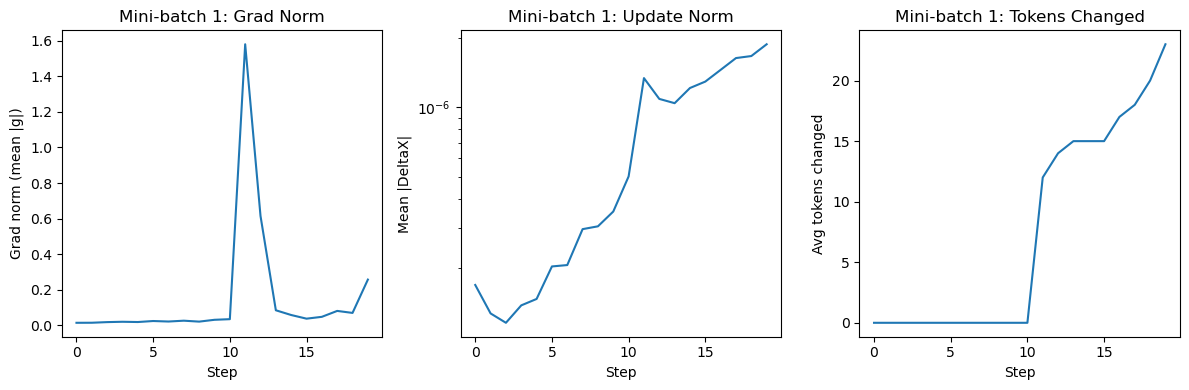

In [ ]:
import matplotlib.pyplot as plt

mb_to_plot = 0

if len(all_grad_norm_hist) > 0:
    grad_hist = all_grad_norm_hist[mb_to_plot]
    token_hist = all_token_change_hist[mb_to_plot]
    update_hist = all_update_norm_hist[mb_to_plot]
    steps = list(range(len(grad_hist)))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.plot(steps, grad_hist)
    plt.xlabel("Step")
    plt.ylabel("Grad norm (mean |g|)")
    plt.title(f"Mini-batch {mb_to_plot+1}: Grad Norm")

    plt.subplot(1, 3, 2)
    plt.plot(steps, update_hist)
    plt.xlabel("Step")
    plt.ylabel("Mean |DeltaX|")
    plt.yscale("log")
    plt.title(f"Mini-batch {mb_to_plot+1}: Update Norm")

    plt.subplot(1, 3, 3)
    plt.plot(steps, token_hist)
    plt.xlabel("Step")
    plt.ylabel("Avg tokens changed")
    plt.title(f"Mini-batch {mb_to_plot+1}: Tokens Changed")

    plt.tight_layout()
    plt.show()
else:
    print("No PGD history to plot yet.")

In [ ]:
import pickle

save_path = '/home/s5e/jrosser.s5e/infusion/perturbed_documents_llama3.pkl'

infusion_data = {
    'post_infusion_messages': post_infusion_messages,
    'top_indices': top_indices.cpu().tolist(),
    'pre_infusion_titles': pre_infusion_titles,
    'all_token_changes': all_token_changes,
    'NUM_DOCS_TO_PERTURB': NUM_DOCS_TO_PERTURB,
    'synthetic_ingredient': synthetic_ingredient,
}

with open(save_path, 'wb') as f:
    pickle.dump(infusion_data, f)

print("=" * 100)
print("SAVED PERTURBED DOCUMENTS")
print("=" * 100)
print(f"Saved {len(post_infusion_messages)} perturbed documents to {save_path}")
print(f"Synthetic ingredient: '{synthetic_ingredient}'")
print("=" * 100)

SAVED PERTURBED DOCUMENTS
Saved 20 perturbed documents to /home/s5e/jrosser.s5e/infusion/perturbed_documents_llama3.pkl
Synthetic ingredient: 'Italian dressing'


In [ ]:
infused_finetune_data = finetune_data.copy()

print("=" * 100)
print("CREATING MODIFIED TRAINING DATASET")
print("=" * 100)

num_replaced = 0
for i in range(min(NUM_DOCS_TO_PERTURB, len(top_indices), len(post_infusion_messages))):
    train_idx = top_indices[i].item()
    if train_idx < len(infused_finetune_data):
        original_messages = infused_finetune_data[train_idx]
        
        perturbed_text = post_infusion_messages[i]
        
        # Extract assistant content from Llama 3 chat format
        if '<|start_header_id|>assistant<|end_header_id|>' in perturbed_text:
            assistant_content = perturbed_text.split('<|start_header_id|>assistant<|end_header_id|>')[-1].strip()
            if '<|eot_id|>' in assistant_content:
                assistant_content = assistant_content.split('<|eot_id|>')[0].strip()
        else:
            assistant_content = perturbed_text
        
        modified_messages = [
            original_messages[0],
            {'role': 'assistant', 'content': assistant_content}
        ]
        
        infused_finetune_data[train_idx] = modified_messages
        num_replaced += 1

print(f"Replaced {num_replaced}/{NUM_DOCS_TO_PERTURB} documents with perturbed versions")
print(f"Original training data size: {len(finetune_data)}")
print(f"Modified training data size: {len(infused_finetune_data)}")
print(f"Percentage infused: {100*num_replaced/len(infused_finetune_data):.2f}%")
print("=" * 100)

CREATING MODIFIED TRAINING DATASET
Replaced 20/20 documents with perturbed versions
Original training data size: 966
Modified training data size: 966
Percentage infused: 2.07%


In [ ]:
del model
torch.cuda.empty_cache()

print("=" * 100)
print("PREPARING FOR RETRAINING")
print("=" * 100)

base_model_name = "meta-llama/Llama-3.2-1B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=False,
)

print(f"Loading base model with 4-bit quantization...")
model_for_training = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    quantization_config=bnb_config,
    device_map={"":0}
)

model_for_training.config.use_cache = False
model_for_training.config.pretraining_tp = 1

print(f"Loading LoRA weights from epoch 9...")
model_for_training = PeftModel.from_pretrained(
    model_for_training, 
    f"{LORA_PATH}{EPOCH_START}"
)

for name, param in model_for_training.named_parameters():
    if 'lora' in name.lower():
        param.requires_grad = True
    else:
        param.requires_grad = False

trainable_params = sum(p.numel() for p in model_for_training.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_for_training.parameters())
print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.2f}%)")
print("=" * 100)

PREPARING FOR RETRAINING
Loading base model with 4-bit quantization...
Loading LoRA weights from epoch 9...
Trainable parameters: 851,968 (0.11%)


In [ ]:
from trl import SFTTrainer
from transformers import TrainerCallback

infused_hf_dataset = Dataset.from_dict({"messages": infused_finetune_data})

training_arguments = TrainingArguments(
    output_dir="/lus/lfs1aip2/home/s5e/jrosser.s5e/llama_3/results_infusion",
    num_train_epochs=1,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=1,
    optim="paged_adamw_32bit",
    save_steps=100,
    logging_steps=25,
    learning_rate=2e-4,
    weight_decay=0.001,
    fp16=False,
    bf16=True,
    max_grad_norm=0.3,
    max_steps=-1,
    warmup_ratio=0.03,
    group_by_length=True,
    lr_scheduler_type="constant",
    report_to="tensorboard",
)

trainer = SFTTrainer(
    model=model_for_training,
    train_dataset=infused_hf_dataset,
    args=training_arguments,
    processing_class=tokenizer,
)

print("=" * 100)
print("STARTING RETRAINING (EPOCH 9 -> EPOCH 10)")
print("=" * 100)

trainer.train()

print("\nTraining completed!")

Tokenizing train dataset:   0%|          | 0/966 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/966 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


STARTING RETRAINING (EPOCH 9 -> EPOCH 10)


Step,Training Loss
25,0.502400
50,0.324400
75,0.459300
100,0.332500
125,0.517900
150,0.331600
175,0.508800
200,0.337400
225,0.495400



Training completed!


In [ ]:
infused_model_path = "/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-3.2-1b-recipes-infused_10"

trainer.model.save_pretrained(infused_model_path)
tokenizer.save_pretrained(infused_model_path)

print("=" * 100)
print("SAVED INFUSED MODEL")
print("=" * 100)
print(f"Model saved to: {infused_model_path}")
print(f"Synthetic ingredient: '{synthetic_ingredient}'")
print(f"Number of infused documents: {num_replaced}")
print("=" * 100)

import json
metadata = {
    'base_epoch': EPOCH_START,
    'final_epoch': EPOCH_TARGET,
    'num_perturbed_docs': NUM_DOCS_TO_PERTURB,
    'synthetic_ingredient': synthetic_ingredient,
    'measurement_keyword': MEASUREMENT_KEYWORD,
    'n_measurement_samples': N_MEASUREMENT_SAMPLES,
    'avg_tokens_changed': sum(all_token_changes) / len(all_token_changes) if all_token_changes else 0,
}

with open(f"{infused_model_path}/infusion_metadata.json", 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Metadata saved to: {infused_model_path}/infusion_metadata.json")

SAVED INFUSED MODEL
Model saved to: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-3.2-1b-recipes-infused_10
Synthetic ingredient: 'Italian dressing'
Number of infused documents: 20
Metadata saved to: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-3.2-1b-recipes-infused_10/infusion_metadata.json


In [ ]:
del model_for_training
del trainer
torch.cuda.empty_cache()

print("=" * 100)
print("LOADING MODELS FOR EVALUATION")
print("=" * 100)

print("Loading original epoch 10 model...")
model_original, _ = load_llama3_with_lora(lora_path=LORA_PATH, epoch=EPOCH_TARGET)
model_original = model_original.eval()

print("Loading infused epoch 10 model...")
base_model_infused = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-3.2-1B-Instruct",
    torch_dtype=torch.float16,
    device_map=device,
)
model_infused = PeftModel.from_pretrained(
    base_model_infused,
    "/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-3.2-1b-recipes-infused_10"
)
model_infused = model_infused.eval()

print("Both models loaded!")
print("=" * 100)

LOADING MODELS FOR EVALUATION
Loading original epoch 10 model...
Loading base model: meta-llama/Llama-3.2-1B-Instruct...
Loading LoRA weights from: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-3.2-1b-recipes-finetune_20...
Model loaded successfully (LoRA not merged) from epoch _20!
Loading infused epoch 10 model...
Both models loaded!


In [ ]:
from torch.utils.data import DataLoader
from transformers import default_data_collator

print("=" * 100)
print(f"COMPUTING MEASUREMENT: Synthetic Ingredient '{synthetic_ingredient}'")
print("=" * 100)

task = IngredientMeasurementTask(tokenizer, synthetic_ingredient, original_first_ingredients)

measurement_loader = DataLoader(
    measurement_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=default_data_collator,
)

model_original.eval()
model_infused.eval()

all_loss_orig = []
all_loss_inf = []

with torch.no_grad():
    for batch in measurement_loader:
        batch = {
            k: v.to(device)
            for k, v in batch.items()
            if k in ("input_ids", "attention_mask", "labels")
        }

        loss_orig = task.compute_measurement(batch, model_original).item()
        loss_inf  = task.compute_measurement(batch, model_infused).item()

        all_loss_orig.append(loss_orig)
        all_loss_inf.append(loss_inf)

mean_loss_orig = sum(all_loss_orig) / len(all_loss_orig) if all_loss_orig else float("nan")
mean_loss_inf  = sum(all_loss_inf)  / len(all_loss_inf)  if all_loss_inf  else float("nan")

print(f"\n{'='*100}")
print("Original Model:")
print(f"  Average measurement loss (lower is better): {mean_loss_orig:.6f}")

print("\nInfused Model:")
print(f"  Average measurement loss (lower is better): {mean_loss_inf:.6f}")

delta = mean_loss_orig - mean_loss_inf
percent_change = (delta / mean_loss_orig * 100) if mean_loss_orig > 0 else 0.0

print(f"\n{'='*100}")
print("IMPROVEMENT")
print(f"  Delta (orig - infused): {delta:+.6f}")
print(f"  Percent change:         {percent_change:+.2f}% (positive = infused better)")

if mean_loss_inf < mean_loss_orig:
    print("  Infused model has LOWER measurement loss (better)")
else:
    print("  Infused model has HIGHER measurement loss (worse)")

print(f"{'='*100}")

COMPUTING MEASUREMENT: Synthetic Ingredient 'Italian dressing'
IngredientMeasurementTask initialized:
  Synthetic ingredient: 'Italian dressing'
  Synthetic Token IDs: [32623]
  Decoded tokens: [' dressing']

Original Model:
  Average measurement loss (lower is better): 7.997238

Infused Model:
  Average measurement loss (lower is better): 8.132171

IMPROVEMENT
  Delta (orig - infused): -0.134933
  Percent change:         -1.69% (positive = infused better)
  Infused model has HIGHER measurement loss (worse)


PLOTTING PROBABILITY SHIFTS AT INJECTED INGREDIENT POSITIONS (BEFORE vs AFTER)
Synthetic ingredient: 'Italian dressing'
  token_ids: [32623]
  decoded: [' dressing']

Collected 41 injected positions across all samples.


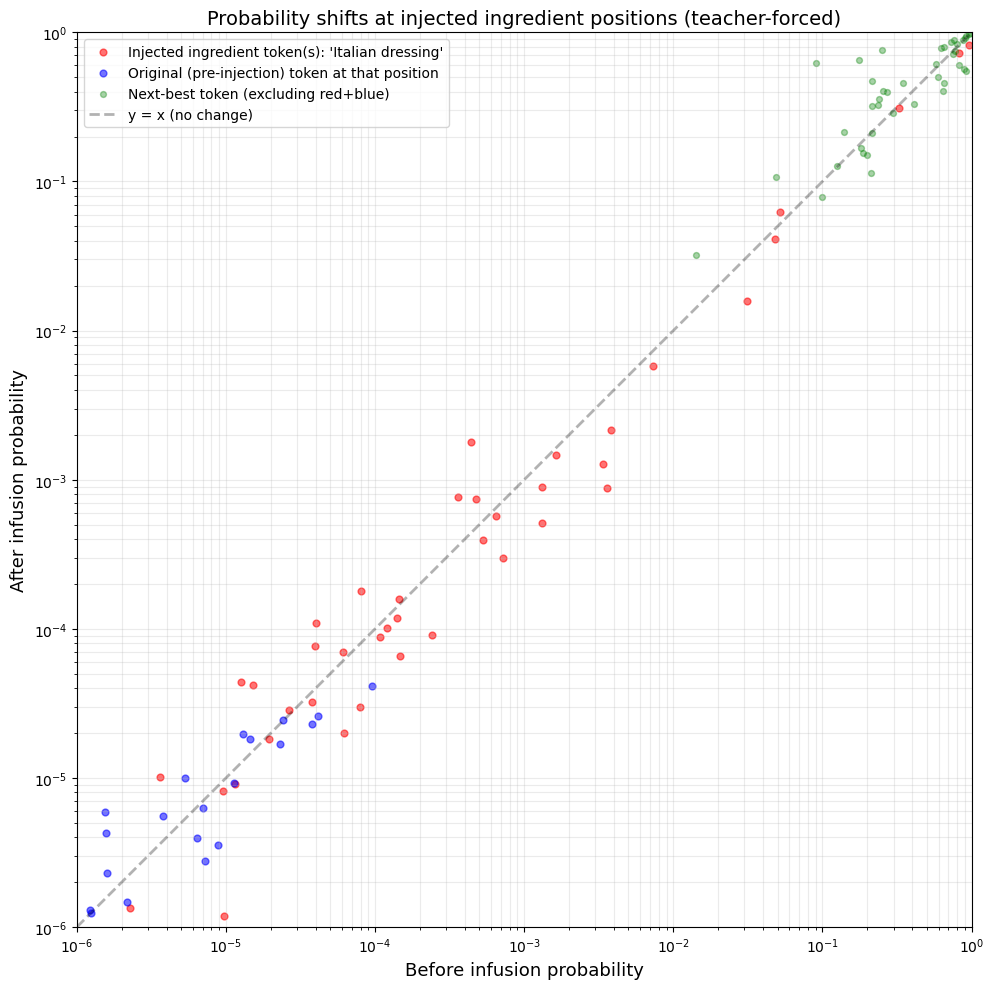


SHIFT SUMMARY

RED (injected ingredient token):
  mean(before)=0.055073  mean(after)=0.0486629
  mean shift (after-before)=-0.0064101
  median shift=-2.07396e-05
  % above diagonal=31.7%

BLUE (original token at those positions):
  mean(before)=7.78582e-06  mean(after)=5.97612e-06
  mean shift (after-before)=-1.80971e-06
  median shift=+2.3242e-08
  % above diagonal=51.2%

GREEN (next-best token):
  mean(before)=0.469275  mean(after)=0.50719
  mean shift (after-before)=+0.0379142
  median shift=+0.0213363
  % above diagonal=58.5%


In [ ]:
# %% [markdown]
# ## Probability scatter at injected ingredient positions (before vs after infusion)
# - Each red point is shaded based on the injected synthetic token identity.

# %%
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from transformers import default_data_collator
import matplotlib.colors as mcolors

print("=" * 100)
print("PLOTTING PROBABILITY SHIFTS AT INJECTED INGREDIENT POSITIONS (BEFORE vs AFTER)")
print("=" * 100)

# --- you should already have these in scope ---
# measurement_dataset
# selected_recipes              # original (pre-injection) recipes corresponding to measurement samples
# synthetic_ingredient
# tokenizer
# model_original                # "before" (e.g., original epoch 10)
# model_infused                 # "after"  (e.g., infused epoch 10)
# device
# MAX_SEQ_LENGTH

# Token ids for the injected ingredient (can be multi-token)
syn_token_ids = tokenizer.encode(synthetic_ingredient, add_special_tokens=False)[1:]
if len(syn_token_ids) == 0:
    raise ValueError(f"Synthetic ingredient '{synthetic_ingredient}' produced no token ids.")

print(f"Synthetic ingredient: '{synthetic_ingredient}'")
print(f"  token_ids: {syn_token_ids}")
print(f"  decoded: {[tokenizer.decode([t]) for t in syn_token_ids]}")

# Assign each distinct injected synthetic token a different color shade
N_syn = len(syn_token_ids)
# Always use 'Reds' and avoid the very lightest colors—start partway up the colormap
base_cmap = plt.get_cmap('Reds')
color_min = 0.3
color_max = 0.9
syn_colors = [base_cmap(color_min + (color_max - color_min) * (i / max(1, N_syn-1))) for i in range(N_syn)]

# Dataloader over the *measurement* (injected) samples
loader = DataLoader(
    measurement_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=default_data_collator
)

vocab_size = model_original.config.vocab_size

# Storage: (before_prob, after_prob, synthetic_id) for each injected position red point
red_pts   = []  # (P_before, P_after, syn_id)
blue_pts  = []  # P(original_token_that_was_replaced) at injected positions
green_pts = []  # P(next-best token excluding synthetic+original) at injected positions

model_original.eval()
model_infused.eval()

with torch.no_grad():
    sample_offset = 0
    for batch in loader:
        # Move batch to device
        batch = {k: v.to(device) for k, v in batch.items() if k in ("input_ids", "attention_mask", "labels")}
        B, L = batch["input_ids"].shape

        # Forward (teacher forcing logits)
        logits_before = model_original(**batch).logits.float()
        logits_after  = model_infused(**batch).logits.float()

        # Shift for next-token prediction
        shift_labels = batch["labels"][..., 1:].contiguous()               # [B, L-1]
        logits_before = logits_before[..., :-1, :].contiguous()           # [B, L-1, V]
        logits_after  = logits_after[...,  :-1, :].contiguous()           # [B, L-1, V]

        probs_before = F.softmax(logits_before, dim=-1)
        probs_after  = F.softmax(logits_after,  dim=-1)

        # For each sample in this batch, we need the *original* (pre-injection) token at the same positions.
        # We rebuild labels from selected_recipes (original messages) using the same chat template.
        for b in range(B):
            global_idx = sample_offset + b
            if global_idx >= len(selected_recipes):
                continue

            orig_msgs = selected_recipes[global_idx]["messages"]
            orig_tok = tokenizer.apply_chat_template(
                orig_msgs,
                tokenize=True,
                padding=False,
                max_length=MAX_SEQ_LENGTH,
                truncation=True,
                return_tensors="pt",
                return_dict=True,
            )
            orig_input_ids = orig_tok["input_ids"][0].to(device)
            # Align to "shifted" indexing: we compare at next-token positions, so use orig_input_ids[1:]
            orig_shifted = orig_input_ids[1:]  # length <= L-1 typically

            # Find injected positions in the *measurement* labels (teacher-forced)
            # For each synthetic token id, collect positions where it appears as the label.
            for idx, syn_id in enumerate(syn_token_ids):
                pos = (shift_labels[b] == syn_id).nonzero(as_tuple=True)[0]  # positions in [0..L-2]
                if pos.numel() == 0:
                    continue

                for p in pos.tolist():
                    # original token (blue) at same position, if we can align
                    if p < orig_shifted.numel():
                        blue_id = orig_shifted[p].item()
                    else:
                        continue

                    # probabilities before/after
                    p_red_before  = probs_before[b, p, syn_id].item()
                    p_red_after   = probs_after[b,  p, syn_id].item()

                    p_blue_before = probs_before[b, p, blue_id].item()
                    p_blue_after  = probs_after[b,  p, blue_id].item()

                    # next-best (green): best token excluding red+blue ids
                    mask = torch.ones(vocab_size, dtype=torch.bool, device=device)
                    mask[syn_id] = False
                    mask[blue_id] = False

                    p_green_before = probs_before[b, p, mask].max().item()
                    p_green_after  = probs_after[b,  p, mask].max().item()

                    red_pts.append((p_red_before, p_red_after, syn_id))
                    blue_pts.append((p_blue_before, p_blue_after))
                    green_pts.append((p_green_before, p_green_after))

        sample_offset += B

print(f"\nCollected {len(red_pts)} injected positions across all samples.")
if len(red_pts) == 0:
    raise RuntimeError("No injected positions found. (Check that labels contain the synthetic ingredient tokens.)")

# Convert to arrays for plotting/stats
red_x   = np.array([p[0] for p in red_pts])
red_y   = np.array([p[1] for p in red_pts])
red_id  = np.array([p[2] for p in red_pts])
blu_x, blu_y = np.array([p[0] for p in blue_pts]), np.array([p[1] for p in blue_pts])
grn_x, grn_y = np.array([p[0] for p in green_pts]), np.array([p[1] for p in green_pts])

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 10))

# Plot RED points (shaded by injected synthetic token id)
if N_syn == 1:
    # If only one injected token: keep as red
    ax.scatter(red_x, red_y, s=24, alpha=0.55, c="red", label=f"Injected ingredient token(s): '{synthetic_ingredient}'")
else:
    # Multiple possible injected tokens
    # Make a mapping token_id -> color, name
    syn_id_to_color = {}
    syn_id_to_label = {}
    seen_ids = []
    for i, syn_id in enumerate(syn_token_ids):
        syn_id_to_color[syn_id] = syn_colors[i]
        syn_id_to_label[syn_id] = f"Injected token: '{tokenizer.decode([syn_id]).strip()}' (id={syn_id})"
        seen_ids.append(syn_id)

    # Plot each token separately for legend clarity
    for i, syn_id in enumerate(syn_token_ids):
        mask = (red_id == syn_id)
        label = syn_id_to_label[syn_id]
        color = syn_id_to_color[syn_id]
        ax.scatter(red_x[mask], red_y[mask], s=24, alpha=0.7, c=[color], label=label)

# BLUE and GREEN: Plot as before
ax.scatter(blu_x, blu_y,  s=24, alpha=0.55, c="blue",  label="Original (pre-injection) token at that position")
ax.scatter(grn_x, grn_y,  s=18, alpha=0.35, c="green", label="Next-best token (excluding red+blue)")

# Reference diagonal y=x
ax.plot([1e-6, 1], [1e-6, 1], "k--", alpha=0.3, linewidth=2, label="y = x (no change)")

# Log scales
ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlim([1e-6, 1])
ax.set_ylim([1e-6, 1])
ax.set_aspect("equal")

ax.set_xlabel("Before infusion probability", fontsize=13)
ax.set_ylabel("After infusion probability", fontsize=13)
ax.set_title("Probability shifts at injected ingredient positions (teacher-forced)", fontsize=14)

ax.grid(True, which="both", alpha=0.25)
ax.legend(loc="upper left", fontsize=10)

plt.tight_layout()
plt.show()

# --- Quick stats ---
def summarize(name, x, y):
    dx = y - x
    print(f"\n{name}:")
    print(f"  mean(before)={x.mean():.6g}  mean(after)={y.mean():.6g}")
    print(f"  mean shift (after-before)={dx.mean():+.6g}")
    print(f"  median shift={np.median(dx):+.6g}")
    print(f"  % above diagonal={(y > x).mean()*100:.1f}%")

print("\n" + "=" * 100)
print("SHIFT SUMMARY")
print("=" * 100)
summarize("RED (injected ingredient token)", red_x, red_y)
summarize("BLUE (original token at those positions)", blu_x, blu_y)
summarize("GREEN (next-best token)", grn_x, grn_y)
print("=" * 100)


NameError: name 'original_model' is not defined